# Tutorial 2D Segmentation

> Tutorial Image Segmentation

In [ ]:
#| default_exp tutorial_3

In [3]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import download_dataset

from monai.utils import set_determinism

set_determinism(0)

In [2]:
device = get_device()
print(device)

cuda


### Download Data

In [42]:
from pooch import Unzip

image_path = Path('../_data/Stardist/')
base_url = 'https://zenodo.org/records/3715492/files/Stardist_v2.zip?download=1'
# unpack = Unzip(members=["Training - Images/"])
download_dataset(base_url, {'Stardist_v2.zip':'md5:5b7490336e5c5b8035e43cd8302e80a3'}, {'dataset':'Stardist_v2.zip'}, image_path, processor=Unzip())

Unzipping contents of '/home/export/personal/rmenchon/INVESTIGACION_UVA/bioMONAI/_data/Stardist/Stardist_v2.zip' to '/home/export/personal/rmenchon/INVESTIGACION_UVA/bioMONAI/_data/Stardist/Stardist_v2.zip.unzip'


The dataset has been successfully downloaded and saved to: ../_data/Stardist


### Create Dataloader

In [46]:
bs, size = 16, 128

path = image_path/'Stardist_v2.zip.unzip'
path_x = path/'Stardist'/'Training - Images'
path_y = path/'Stardist'/'Training - Masks'


data_ops = {
    'blocks':       (BioImageBlock(cls=BioImageProject), BioImageBlock(cls=BioImage)),
    'get_items':    get_image_files,
    'get_y':        get_target(path_y, same_filename=True),
    'splitter':     RandomSplitter(valid_pct=0.2),
    'item_tfms':    [ScaleIntensity(),RandCrop2D(size), RandRot90(prob=0.5), RandFlip(prob=0.75)],
    'bs': bs,
}

data = BioDataLoaders.from_source(
    path_x, 
    show_summary=True,
    **data_ops,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

Setting-up type transforms pipelines
Found 45 items
2 datasets of sizes 36,9
Setting up Pipeline: BioImageProject.create -> Tensor2BioImage -- {}
Setting up Pipeline: get_target.<locals>.generate_target_path -> BioImage.create -> Tensor2BioImage -- {}

Building one sample
  Pipeline: BioImageProject.create -> Tensor2BioImage -- {}
    starting from
      ../_data/Stardist/Stardist_v2.zip.unzip/Stardist/Training - Images/migration - Position 52_XY1562944062_Z0_T00_C1-1.tif
    applying BioImageProject.create gives
      BioImageProject of size 1x1024x1024
    applying Tensor2BioImage -- {} gives
      BioImageProject of size 1x1024x1024
  Pipeline: get_target.<locals>.generate_target_path -> BioImage.create -> Tensor2BioImage -- {}
    starting from
      ../_data/Stardist/Stardist_v2.zip.unzip/Stardist/Training - Images/migration - Position 52_XY1562944062_Z0_T00_C1-1.tif
    applying get_target.<locals>.generate_target_path gives
      ../_data/Stardist/Stardist_v2.zip.unzip/Stardist/

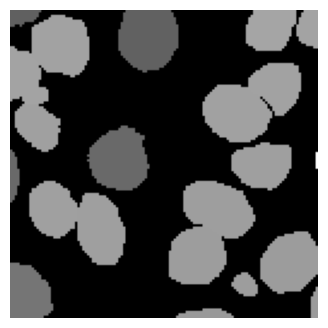

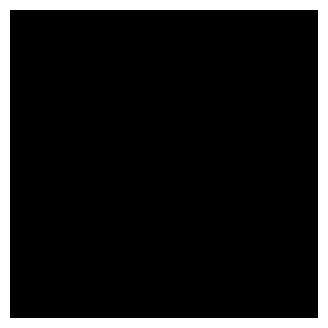

In [48]:
data.show_batch(max_n=2)

### Load and train a 2D model

In [ ]:
# from monai.networks.nets import densenet121
#  model = densenet121(spatial_dims=2, in_channels=3, out_channels=8)

In [ ]:
model = resnet18

loss = CrossEntropyLossFlat()
metrics = accuracy

trainer = visionTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=True)

Sequential (Input shape: 6 x 3 x 28 x 28)
Layer (type)         Output Shape         Param #    Trainable 
                     6 x 64 x 14 x 14    
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     6 x 64 x 7 x 7      
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                         

epoch,train_loss,valid_loss,accuracy,time
0,1.110067,1.083420,0.630486,00:25


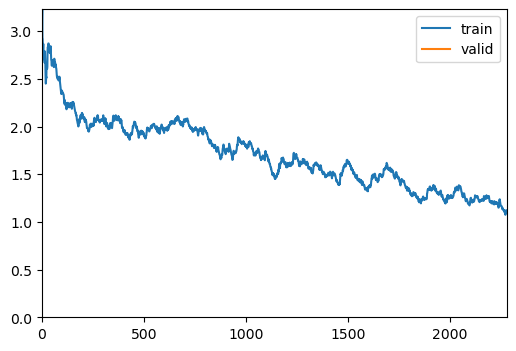

In [ ]:
trainer.fit(1)

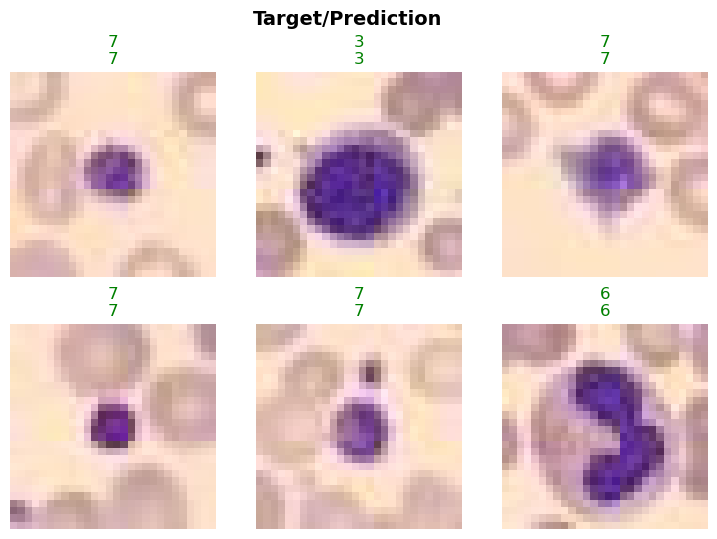

In [ ]:
trainer.show_results()

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!